# TTP Metaheuristics

In [31]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))

from core.ttp_loader import load_instance
from core.ttp_evaluator import TTPEvaluator
from solvers.aco_solver import ACOSolver
from solvers.gwo_solver import GWOSolver
from solvers.ga_solver import GA
from solvers.ga_improved_solver import GAImproved
from solvers.sa_solver import SA
from solvers.sa_improved_solver import SAImproved
from solvers.s5_solver import S5Solver
from solvers.brute_force_solver import BruteForceSolver
from visuals.convergence import plot_convergence
from visuals.tour_map import plot_tour, plot_tour_with_weight_profit, trace_to_dataframe, results_summary
from visuals.animations import animate_weight_profit
import matplotlib.pyplot as plt
import pandas as pd

INSTANCES = {
    "tiny9": "benchmarks/tiny/tiny_n9_m8.ttp",
    "tiny7": "benchmarks/tiny/tiny_n7_m6.ttp",
    "tiny5": "benchmarks/tiny/tiny_n5_m4.ttp",
    "eil51_uncorr": "benchmarks/eil51/eil51_n50_uncorr_01.ttp",
    "eil51_corr":   "benchmarks/eil51/eil51_n50_bounded-strongly-corr_01.ttp",
}

SOLVERS = {
    "ACO":         lambda: ACOSolver(max_iterations=1000),
    "GWO":         lambda: GWOSolver(max_iterations=1000),
    "GA":          lambda: GA(max_iterations=1000),
    "GA_Improved": lambda: GAImproved(max_iterations=1000),
    "SA":          lambda: SA(),
    "SA_Improved": lambda: SAImproved(),
    "S5":          lambda: S5Solver(),
}

RUNS = 3
INSTANCE_NAME = "tiny7"  # change to switch instance
RUN_BRUTE_FORCE = True   # exhaustive search only safe on tiny 

os.makedirs("results", exist_ok=True)
all_results = {}
instance = load_instance(INSTANCES[INSTANCE_NAME])
print(f"Loaded: {INSTANCE_NAME}  ({instance.n} cities, {instance.m} items)")
print(f"Capacity={instance.capacity:.0f}  v_min={instance.v_min}  v_max={instance.v_max}  renting_rate={instance.renting_rate}")

FileNotFoundError: [Errno 2] No such file or directory: 'benchmarks/tiny/tiny_n7_m6.ttp'

## ACO

,score,runtime_s
run,,
1,115.232118,0.064470
2,115.232118,0.092083
3,115.232118,0.099820


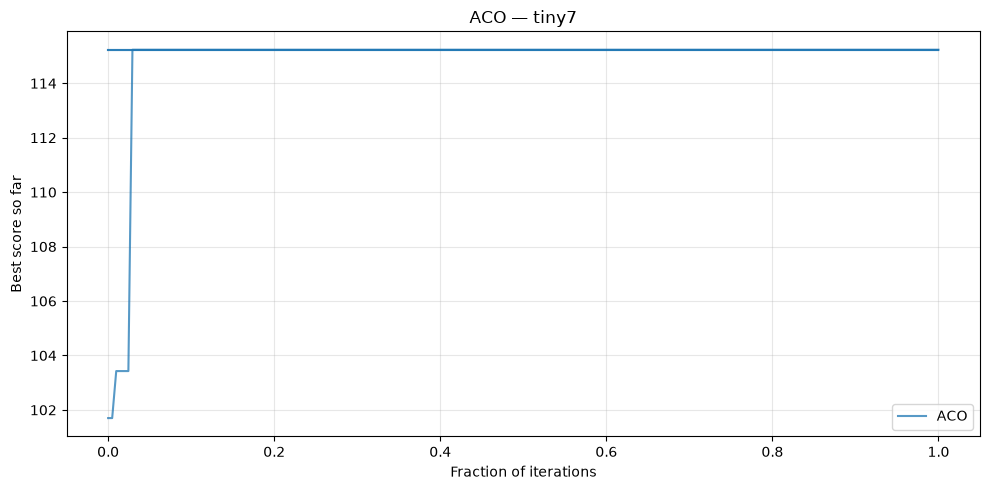

In [ ]:
algo_name = "ACO"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

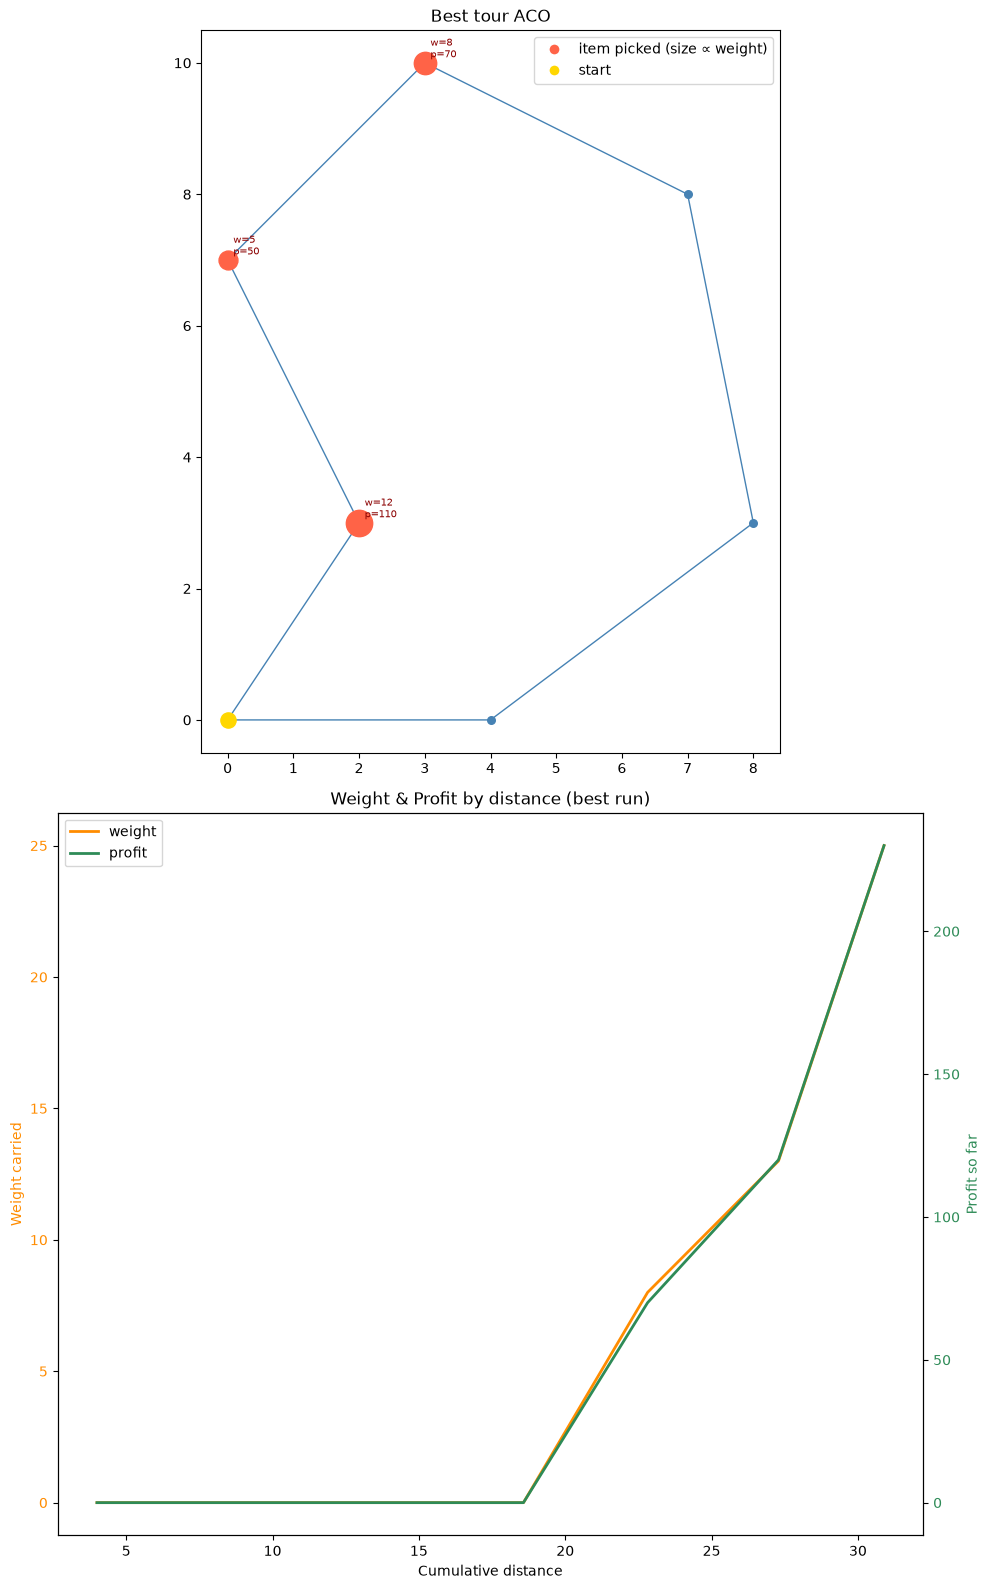

Animation saved to results/aco_weight_profit.gif


In [ ]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [ ]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,1,[],0.0,0.0,4.000000,4.000000,-10.000000
1,1,2,[],0.0,0.0,5.000000,5.000000,-22.500000
2,2,3,[],0.0,0.0,5.099020,5.099020,-35.247549
3,3,4,[],0.0,0.0,4.472136,4.472136,-46.427889
4,4,5,[3],8.0,70.0,4.242641,5.582422,9.616056
5,5,6,[4],13.0,120.0,4.472136,7.331370,41.287630
6,6,0,[5],25.0,230.0,3.605551,14.422205,115.232118


## GWO

,score,runtime_s
run,,
1,110.395659,0.026880
2,110.395659,0.030887
3,50.540192,0.023555


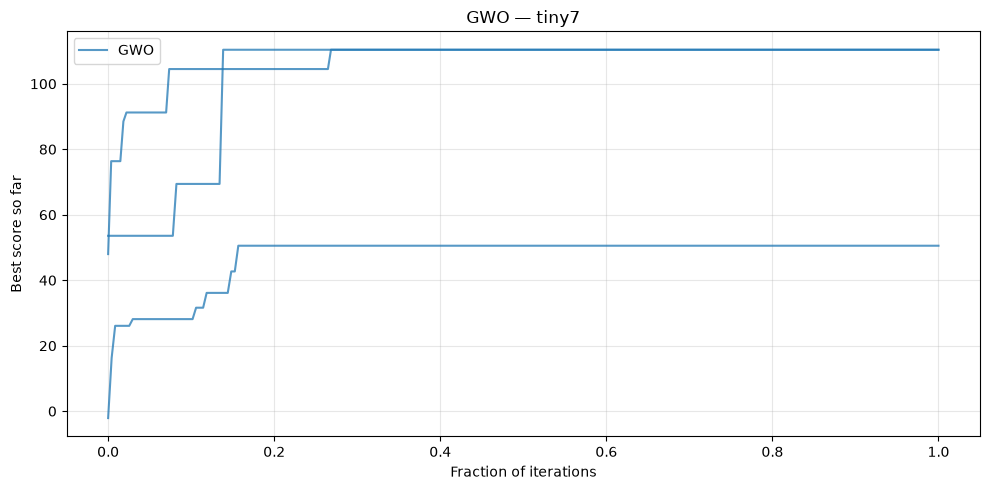

In [ ]:
algo_name = "GWO"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

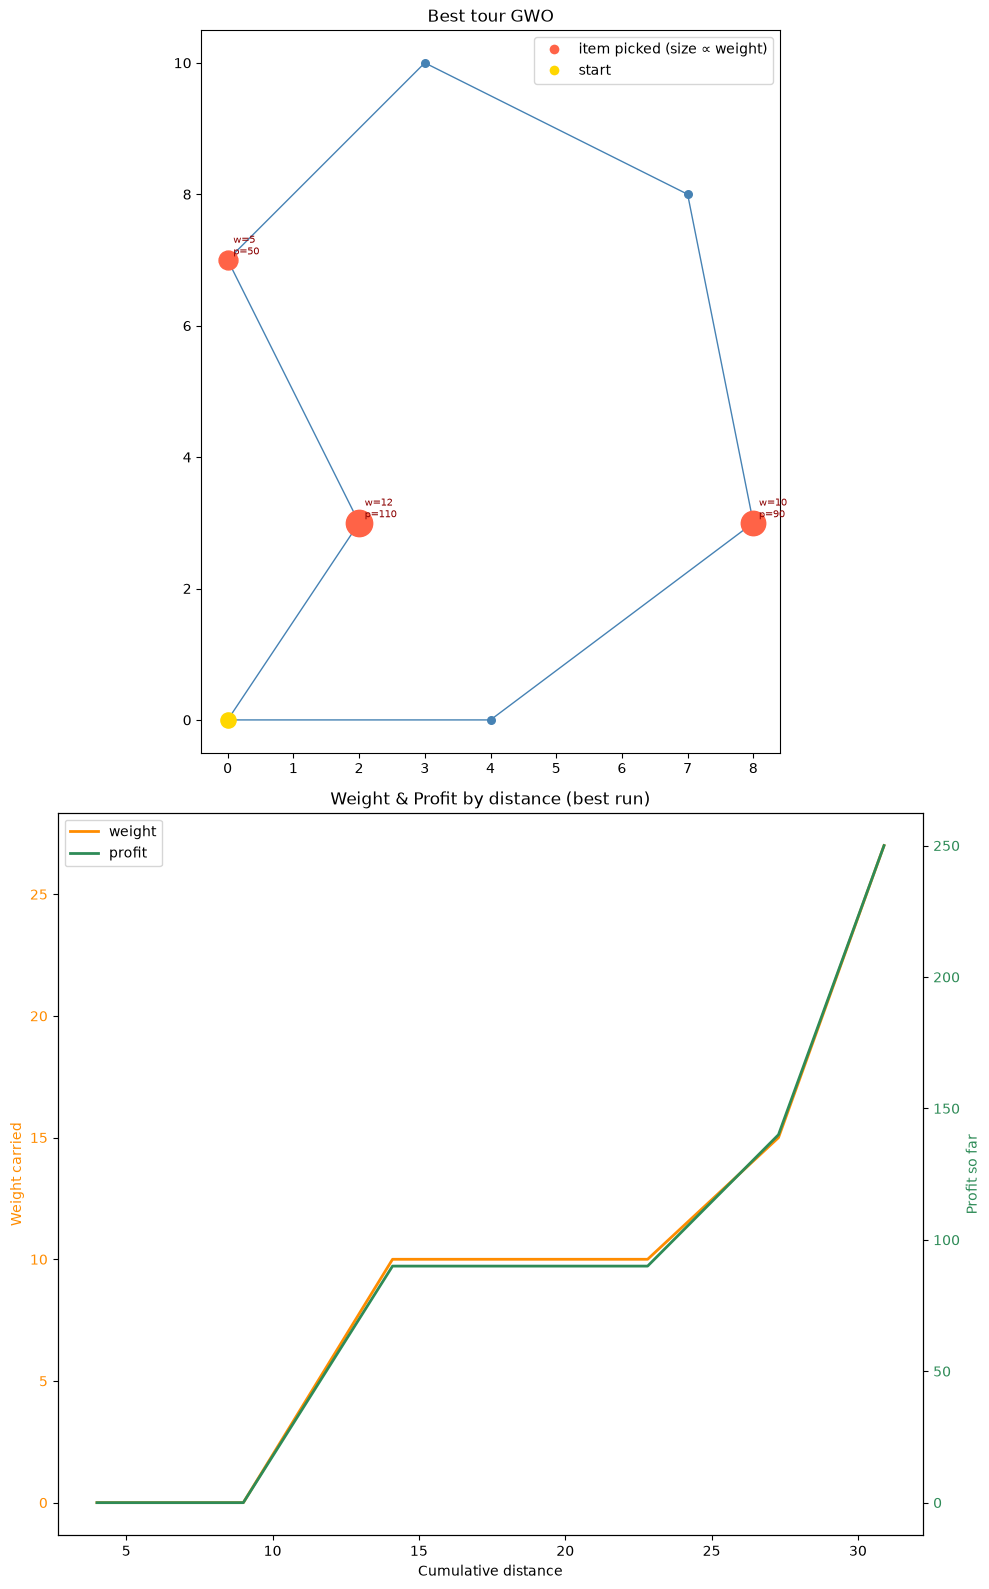

Animation saved to results/gwo_weight_profit.gif


In [ ]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [ ]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,1,[],0.0,0.0,4.000000,4.000000,-10.000000
1,1,2,[],0.0,0.0,5.000000,5.000000,-22.500000
2,2,3,[1],10.0,90.0,5.099020,7.284314,49.289216
3,3,4,[],10.0,90.0,4.472136,6.388766,33.317302
4,4,5,[],10.0,90.0,4.242641,6.060915,18.165014
5,5,6,[4],15.0,140.0,4.472136,8.131156,47.837123
6,6,0,[5],27.0,250.0,3.605551,18.976586,110.395659


## GA

,score,runtime_s
run,,
1,110.395659,0.282406
2,110.395659,0.331337
3,108.952167,0.276748


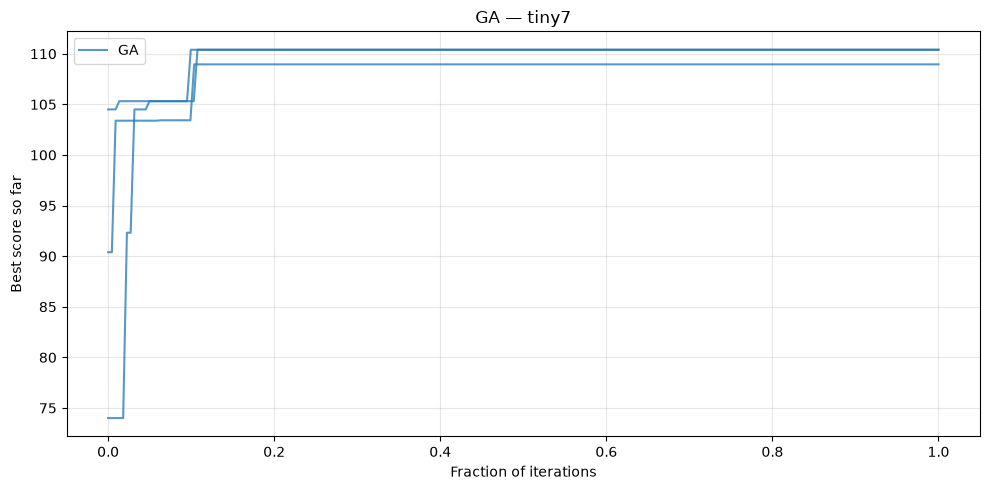

In [ ]:
algo_name = "GA"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

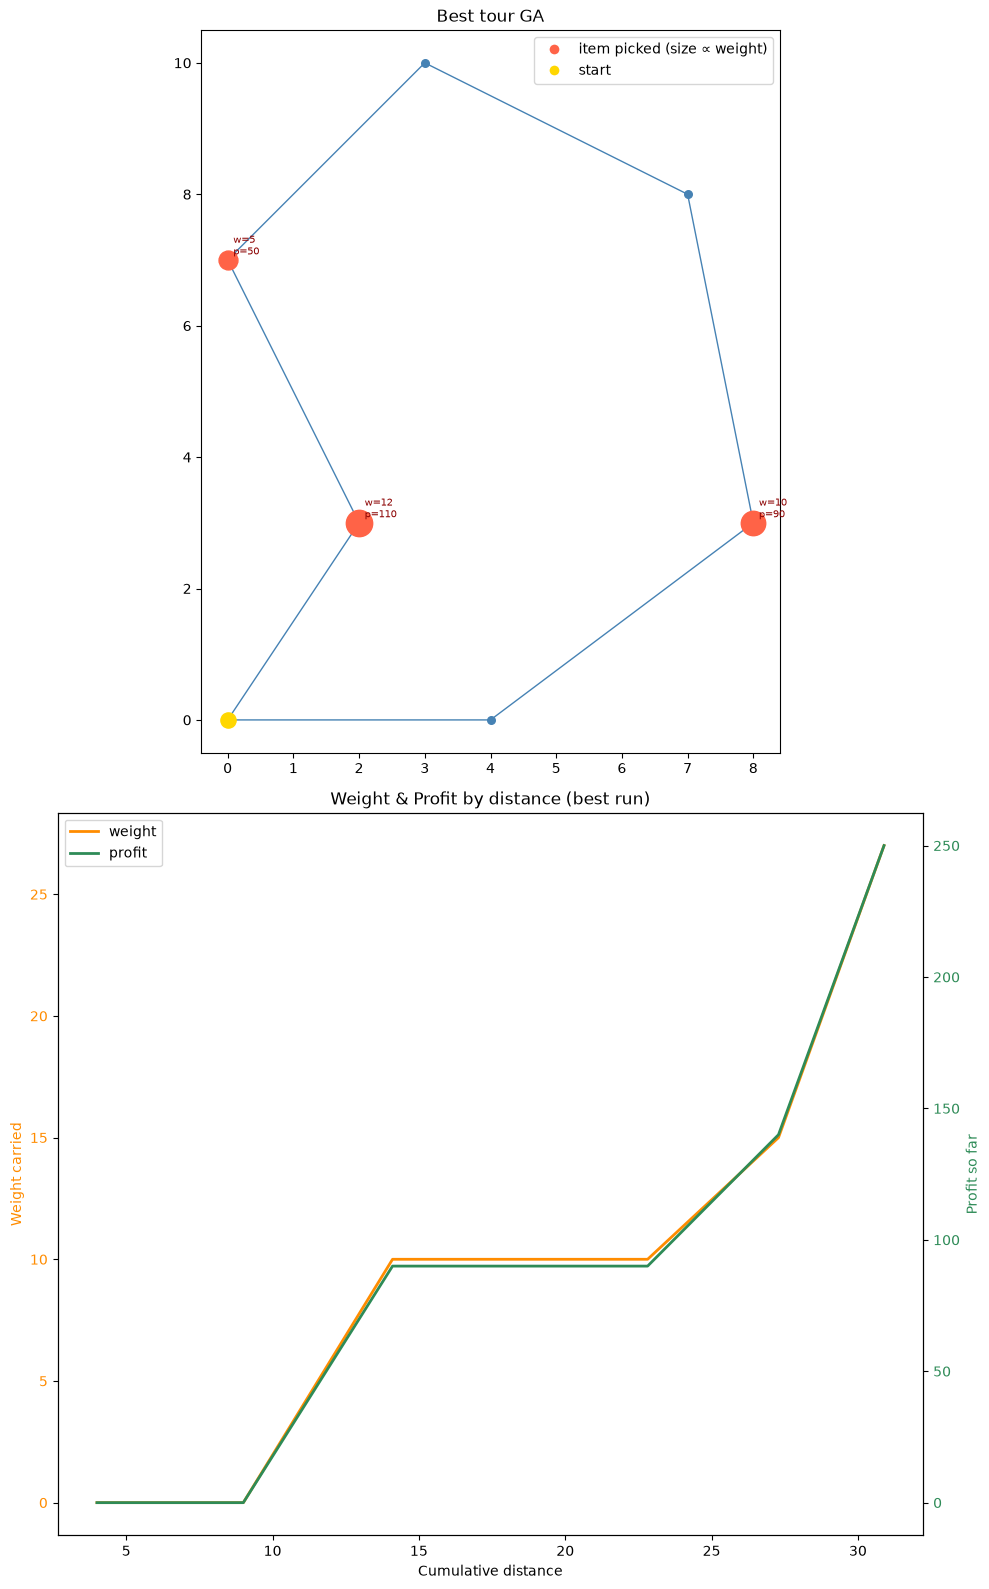

Animation saved to results/ga_weight_profit.gif


In [ ]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [ ]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,1,[],0.0,0.0,4.000000,4.000000,-10.000000
1,1,2,[],0.0,0.0,5.000000,5.000000,-22.500000
2,2,3,[1],10.0,90.0,5.099020,7.284314,49.289216
3,3,4,[],10.0,90.0,4.472136,6.388766,33.317302
4,4,5,[],10.0,90.0,4.242641,6.060915,18.165014
5,5,6,[4],15.0,140.0,4.472136,8.131156,47.837123
6,6,0,[5],27.0,250.0,3.605551,18.976586,110.395659


## GA Improved

,score,runtime_s
run,,
1,101.699863,0.095273
2,101.699863,0.090033
3,101.699863,0.087410


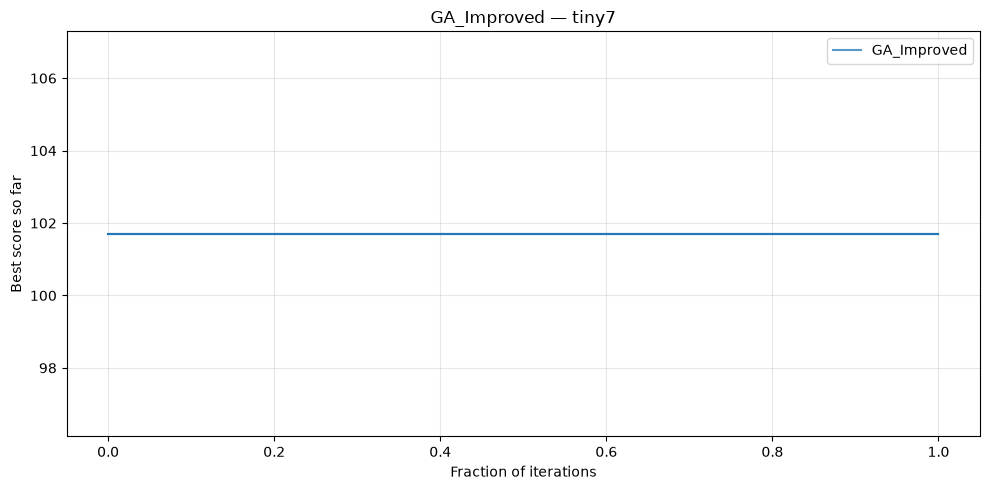

In [ ]:
algo_name = "GA_Improved"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

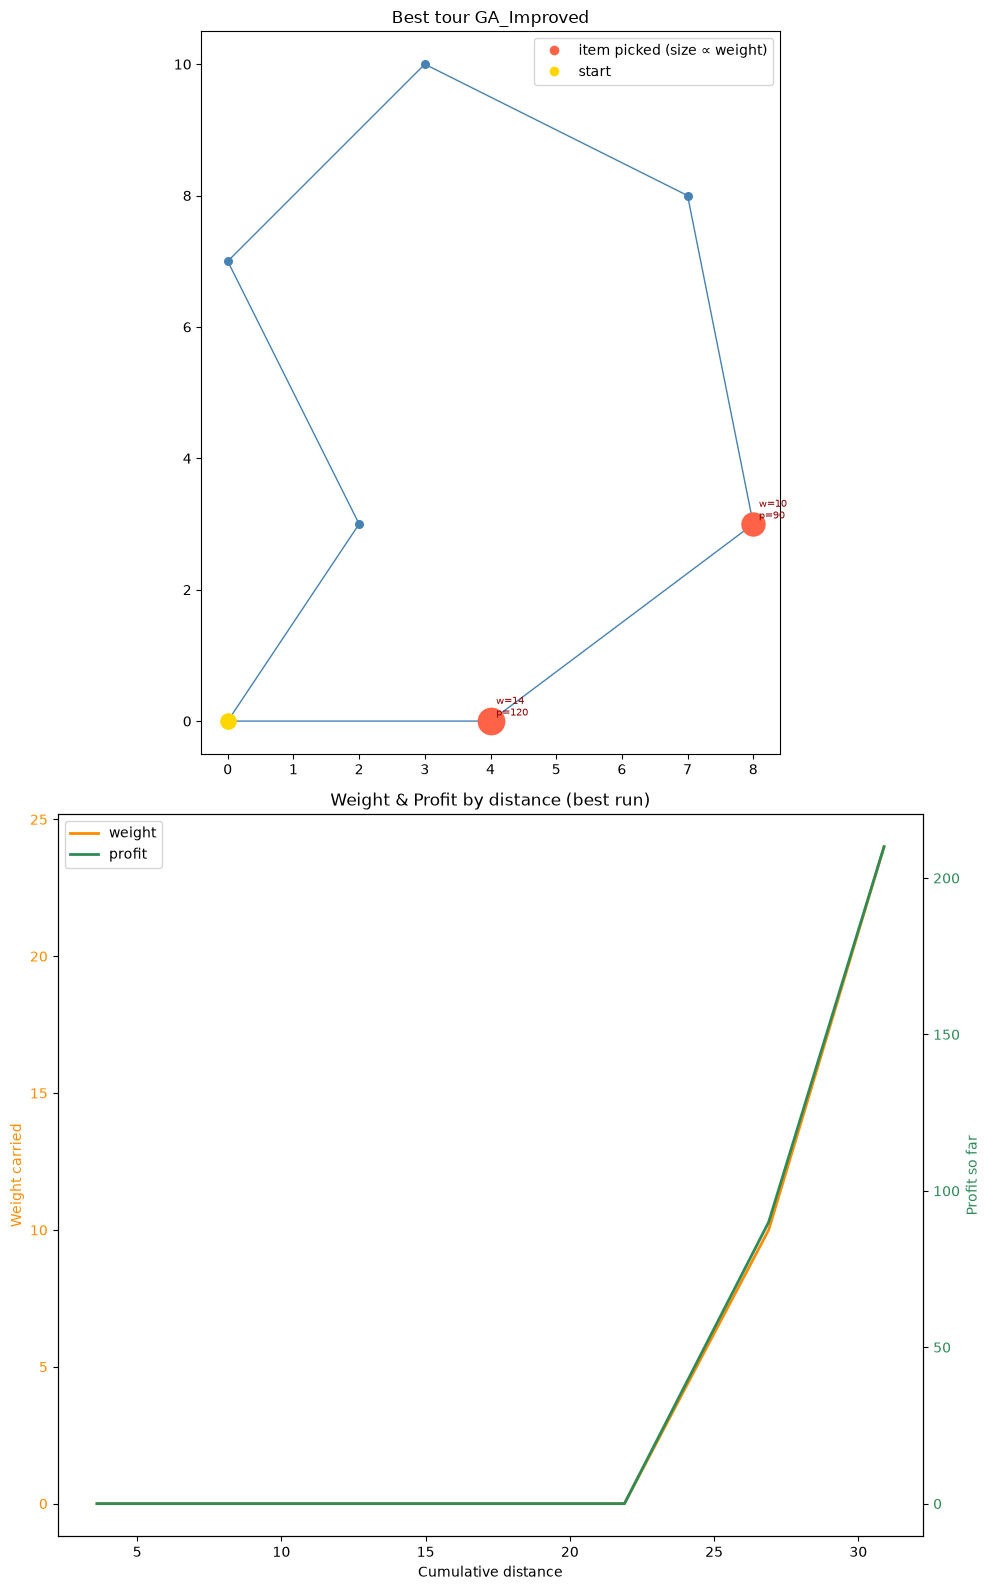

Animation saved to results/ga_improved_weight_profit.gif


In [ ]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [ ]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,6,[],0.0,0.0,3.605551,3.605551,-9.013878
1,6,5,[],0.0,0.0,4.472136,4.472136,-20.194218
2,5,4,[],0.0,0.0,4.242641,4.242641,-30.800820
3,4,3,[],0.0,0.0,4.472136,4.472136,-41.981160
4,3,2,[],0.0,0.0,5.099020,5.099020,-54.728708
5,2,1,[1],10.0,90.0,5.000000,7.142857,17.414149
6,1,0,[0],24.0,210.0,4.000000,14.285714,101.699863


## SA

,score,runtime_s
run,,
1,110.395659,0.119015
2,115.232118,0.099523
3,108.952167,0.100599


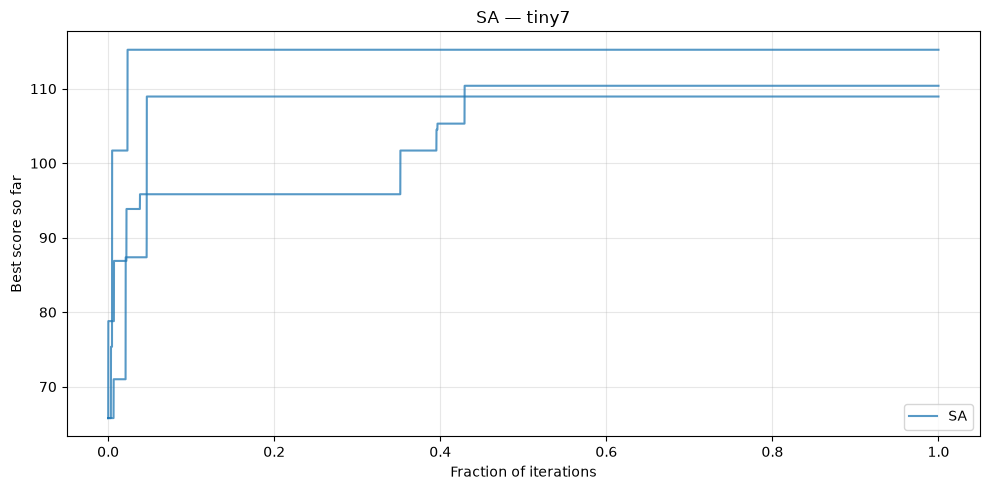

In [ ]:
algo_name = "SA"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

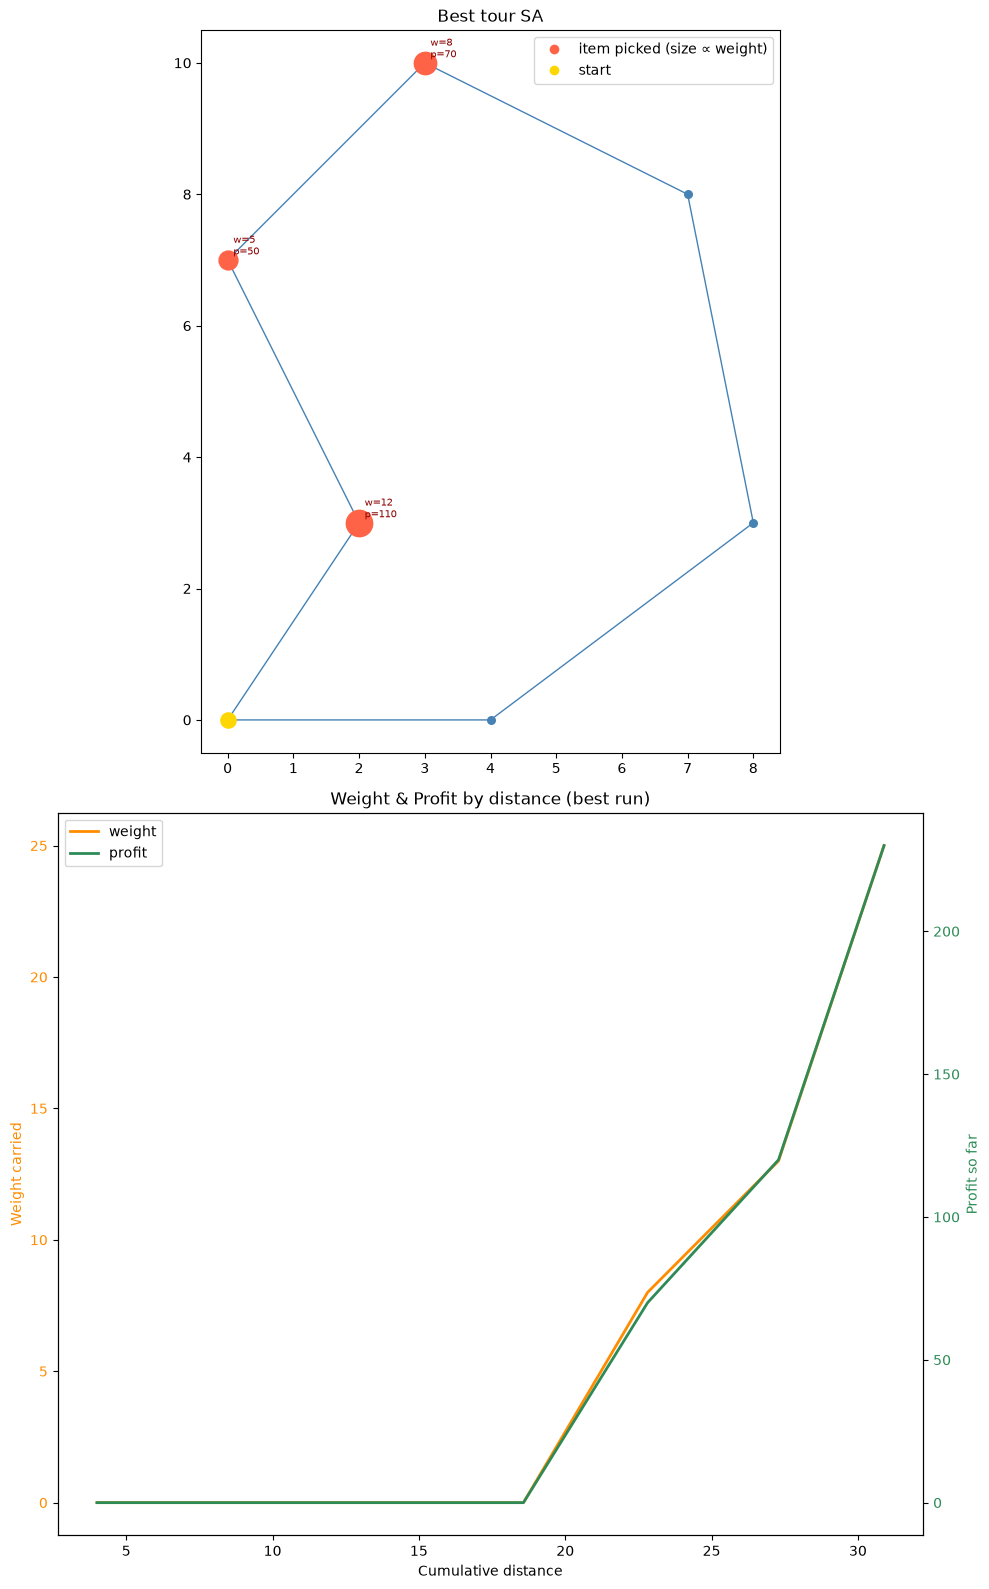

Animation saved to results/sa_weight_profit.gif


In [ ]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [ ]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,1,[],0.0,0.0,4.000000,4.000000,-10.000000
1,1,2,[],0.0,0.0,5.000000,5.000000,-22.500000
2,2,3,[],0.0,0.0,5.099020,5.099020,-35.247549
3,3,4,[],0.0,0.0,4.472136,4.472136,-46.427889
4,4,5,[3],8.0,70.0,4.242641,5.582422,9.616056
5,5,6,[4],13.0,120.0,4.472136,7.331370,41.287630
6,6,0,[5],25.0,230.0,3.605551,14.422205,115.232118


## SA Improved

,score,runtime_s
run,,
1,115.232118,0.421320
2,115.232118,0.400054
3,115.232118,0.425507


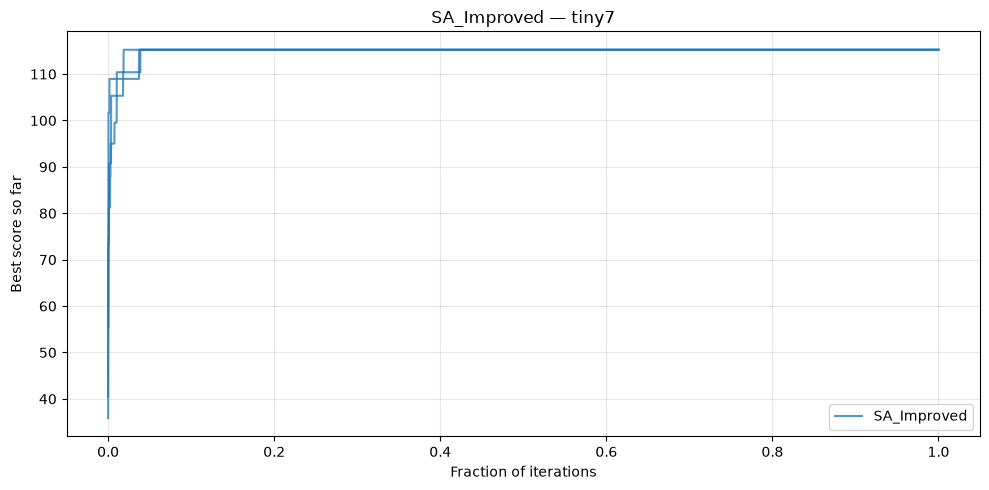

In [ ]:
algo_name = "SA_Improved"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

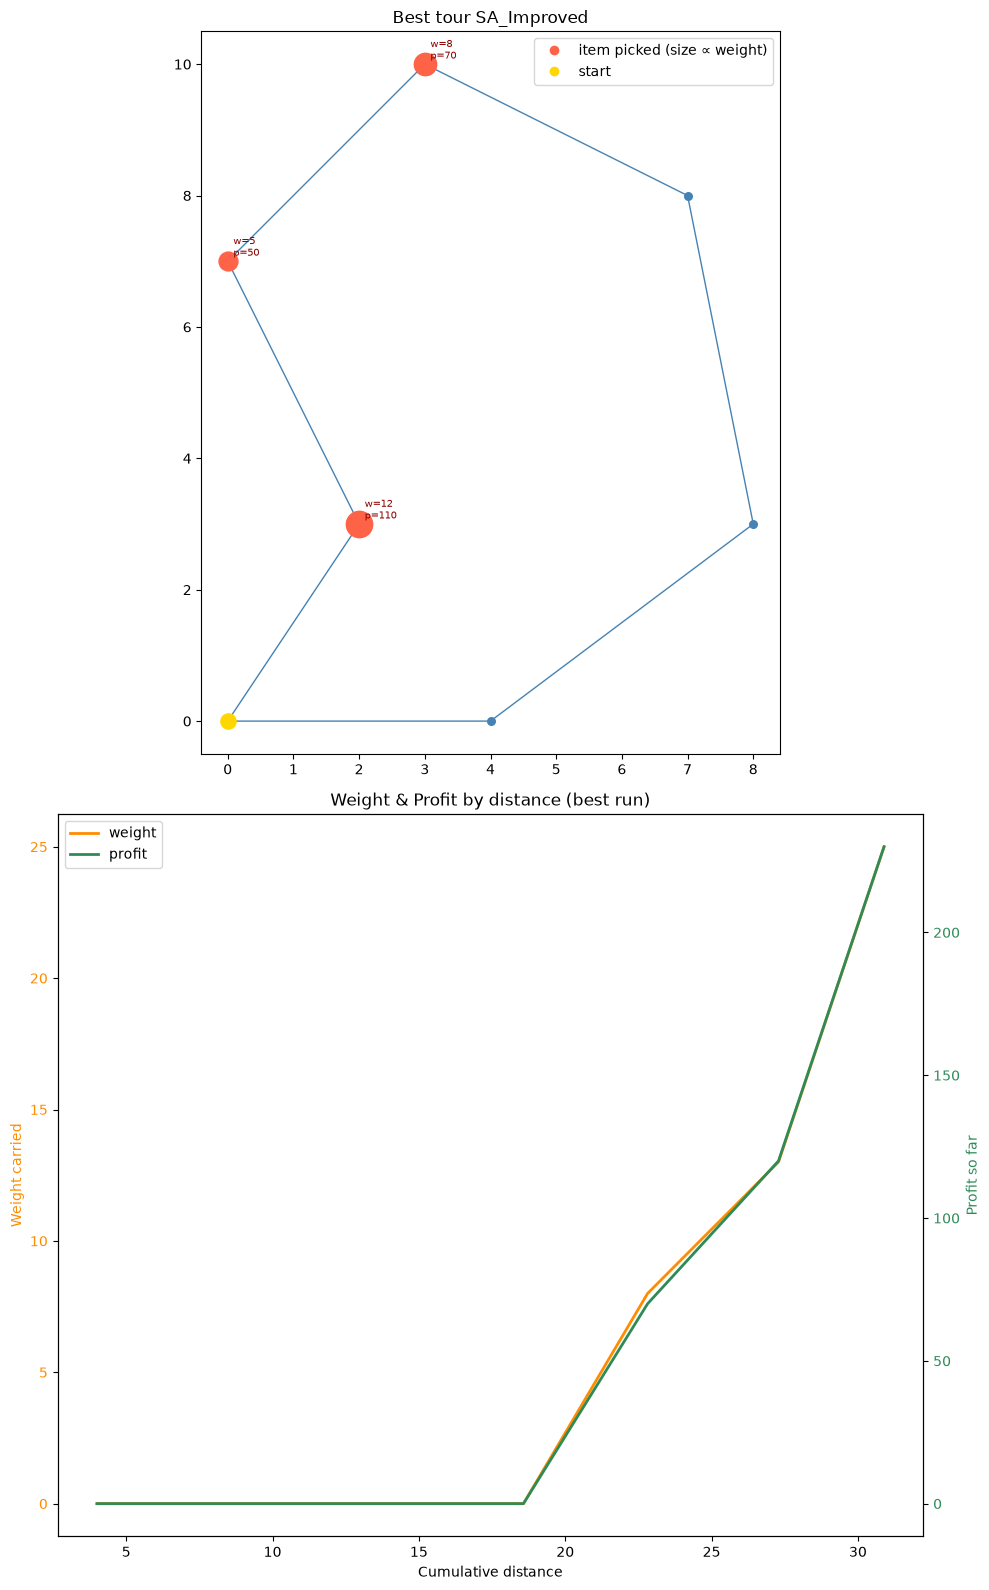

Animation saved to results/sa_improved_weight_profit.gif


In [ ]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [ ]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,1,[],0.0,0.0,4.000000,4.000000,-10.000000
1,1,2,[],0.0,0.0,5.000000,5.000000,-22.500000
2,2,3,[],0.0,0.0,5.099020,5.099020,-35.247549
3,3,4,[],0.0,0.0,4.472136,4.472136,-46.427889
4,4,5,[3],8.0,70.0,4.242641,5.582422,9.616056
5,5,6,[4],13.0,120.0,4.472136,7.331370,41.287630
6,6,0,[5],25.0,230.0,3.605551,14.422205,115.232118


## S5

,score,runtime_s
run,,
1,65.780103,0.000192
2,65.780103,0.000137
3,65.780103,0.000126


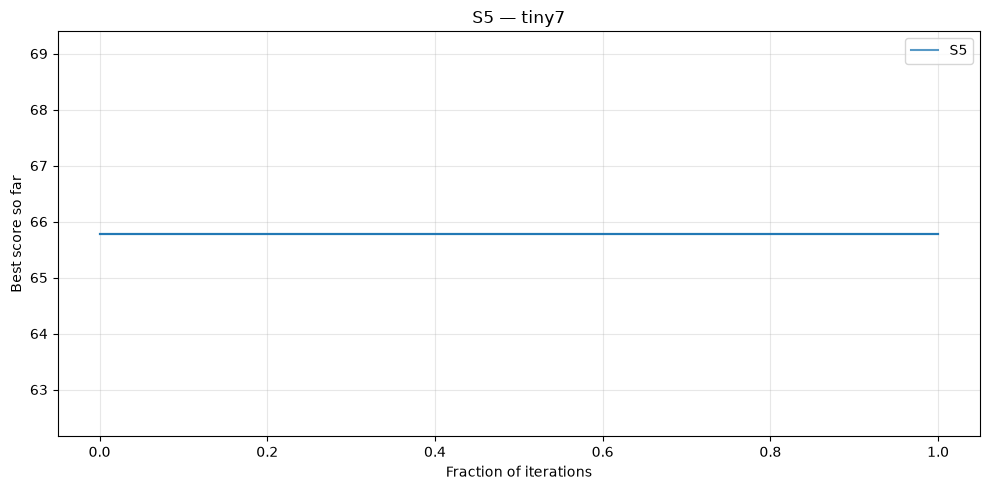

In [ ]:
algo_name = "S5"
results = [SOLVERS[algo_name]().solve(instance) for _ in range(RUNS)]
all_results[algo_name] = results
display(results_summary(results))
plot_convergence(results, title=f"{algo_name} — {INSTANCE_NAME}")
plt.show()

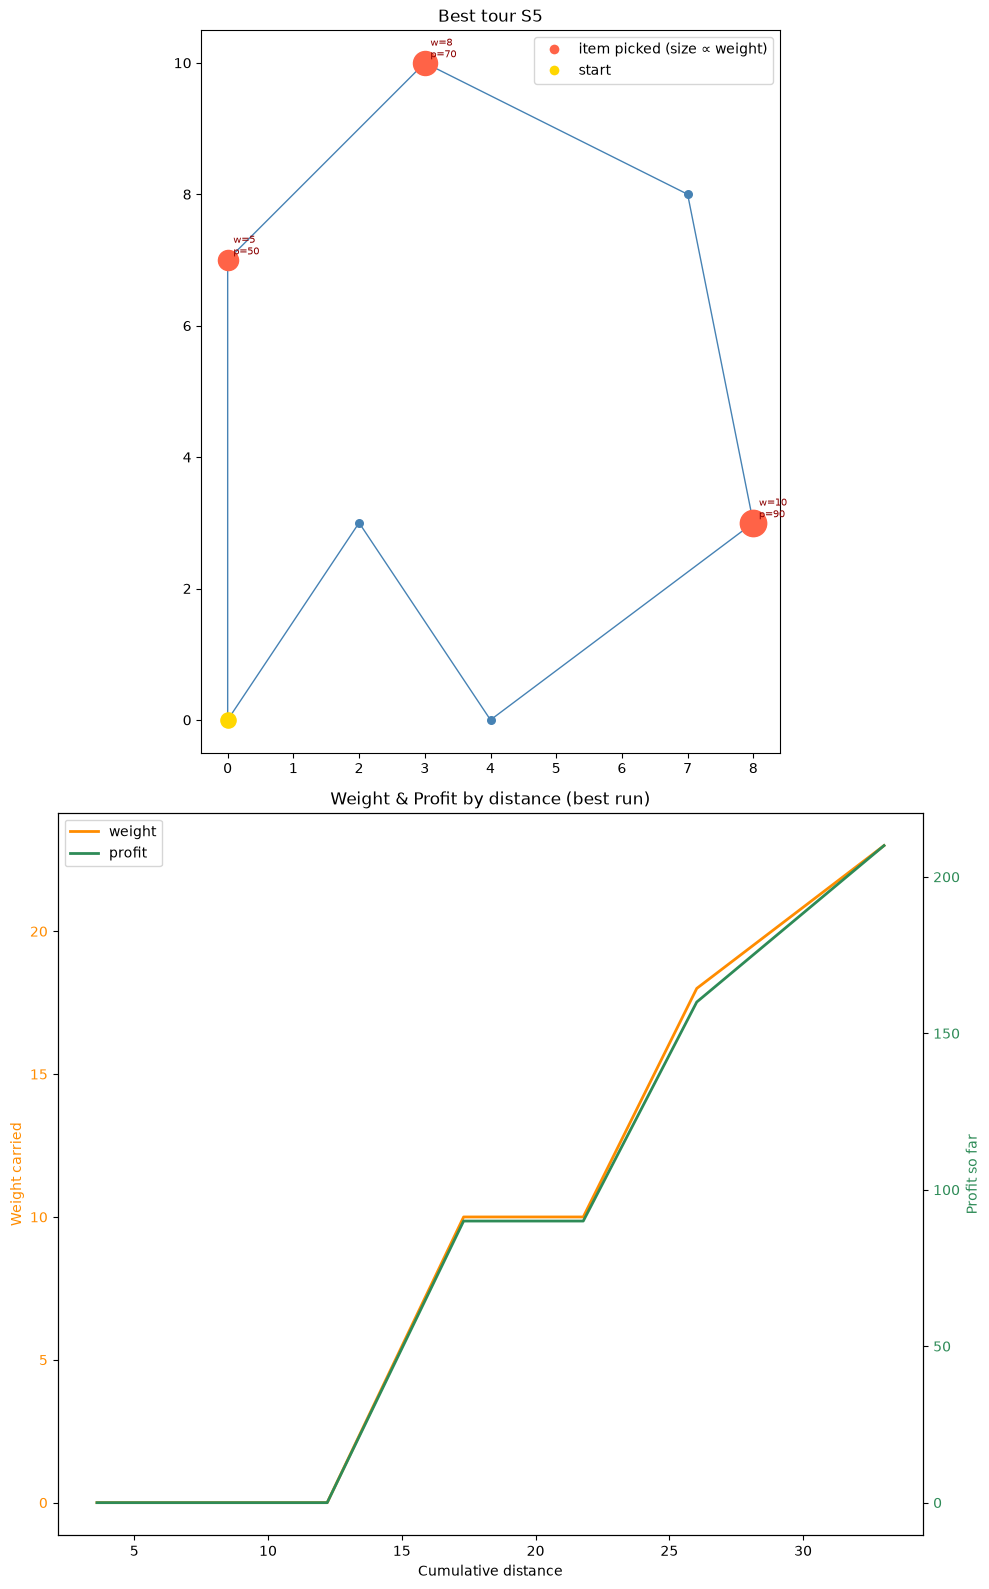

Animation saved to results/s5_weight_profit.gif


In [ ]:
best_result = max(results, key=lambda r: r.convergence[-1])
fig, trace = plot_tour_with_weight_profit(instance, best_result, algo_name)
plt.show()

gif_path = f"results/{algo_name.lower()}_weight_profit.gif"
anim = animate_weight_profit(instance, trace)
anim.save(gif_path, writer="pillow", fps=10)
plt.close(anim._fig)
print(f"Animation saved to {gif_path}")

In [ ]:
trace_to_dataframe(trace)

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,6,[],0.0,0.0,3.605551,3.605551,-9.013878
1,6,1,[],0.0,0.0,3.605551,3.605551,-18.027756
2,1,2,[],0.0,0.0,5.000000,5.000000,-30.527756
3,2,3,[1],10.0,90.0,5.099020,7.284314,41.261460
4,3,4,[],10.0,90.0,4.472136,6.388766,25.289546
5,4,5,[3],18.0,160.0,4.242641,9.223132,72.231716
6,5,0,[4],23.0,210.0,7.000000,22.580645,65.780103


## Brute Force

> **Warning:** exhaustive search over all `(n-1)! × 2^m` combinations. Only run on tiny toy instances (n ≤ 8, m ≤ 15).

,score,runtime_s
run,,
1,115.232118,0.245464


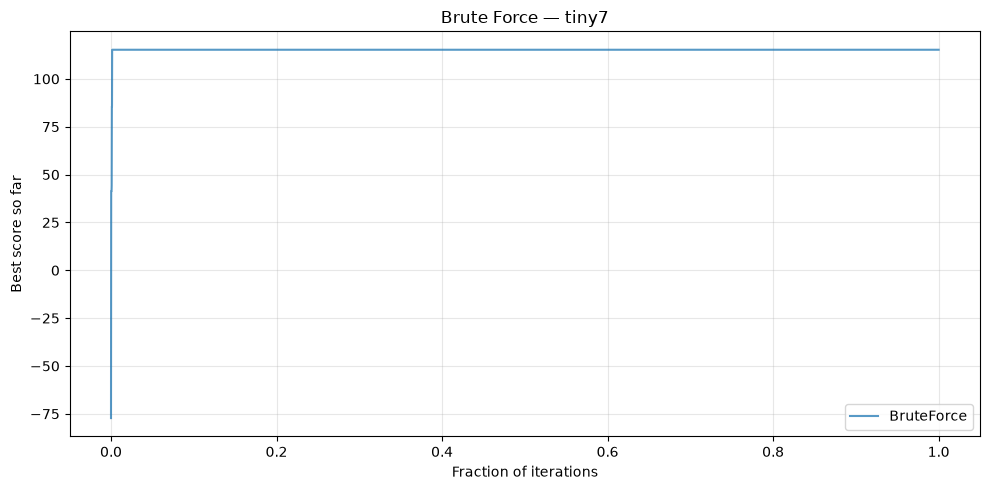

In [ ]:
if RUN_BRUTE_FORCE:
    bf_result = BruteForceSolver().solve(instance)
    all_results["Brute Force"] = [bf_result]
    display(results_summary([bf_result]))
    plot_convergence([bf_result], title=f"Brute Force — {INSTANCE_NAME}")
    plt.show()

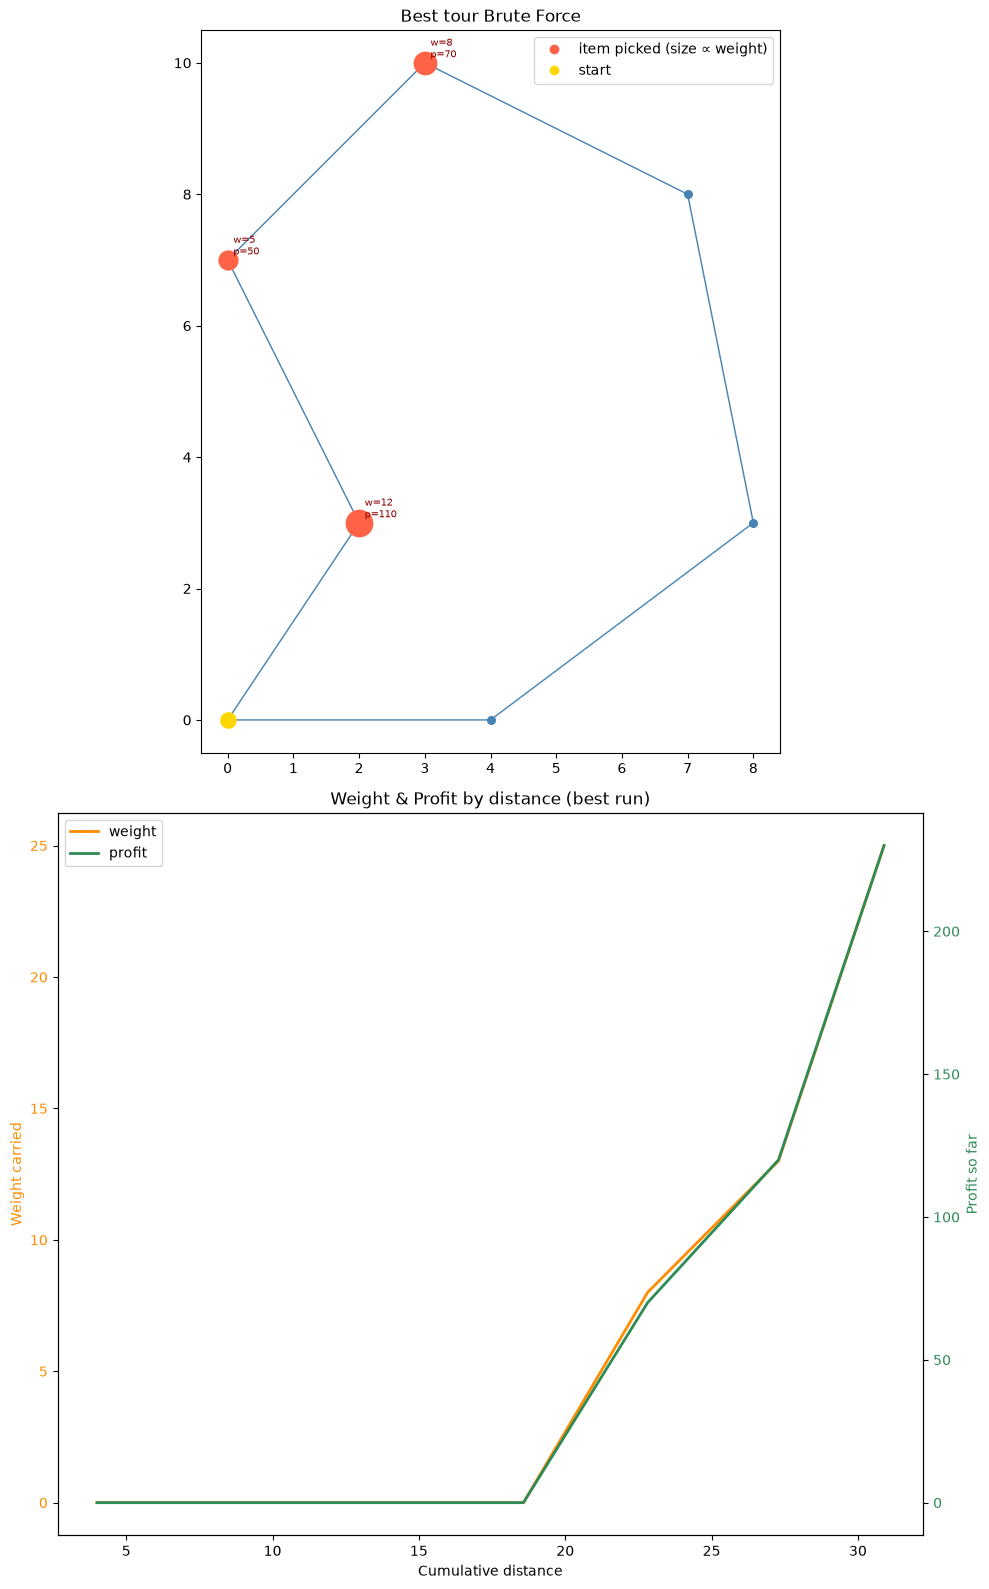

Animation saved to results/brute_force_weight_profit.gif


In [ ]:
if RUN_BRUTE_FORCE:
    fig, trace = plot_tour_with_weight_profit(instance, bf_result, "Brute Force")
    plt.show()

    anim = animate_weight_profit(instance, trace)
    anim.save("results/brute_force_weight_profit.gif", writer="pillow", fps=10)
    plt.close(anim._fig)
    print("Animation saved to results/brute_force_weight_profit.gif")

In [ ]:
if RUN_BRUTE_FORCE:
    display(trace_to_dataframe(trace))

,city,next_city,items_picked,weight,profit_so_far,distance,time,objective_so_far
step,,,,,,,,
0,0,1,[],0.0,0.0,4.000000,4.000000,-10.000000
1,1,2,[],0.0,0.0,5.000000,5.000000,-22.500000
2,2,3,[],0.0,0.0,5.099020,5.099020,-35.247549
3,3,4,[],0.0,0.0,4.472136,4.472136,-46.427889
4,4,5,[3],8.0,70.0,4.242641,5.582422,9.616056
5,5,6,[4],13.0,120.0,4.472136,7.331370,41.287630
6,6,0,[5],25.0,230.0,3.605551,14.422205,115.232118


## Comparison

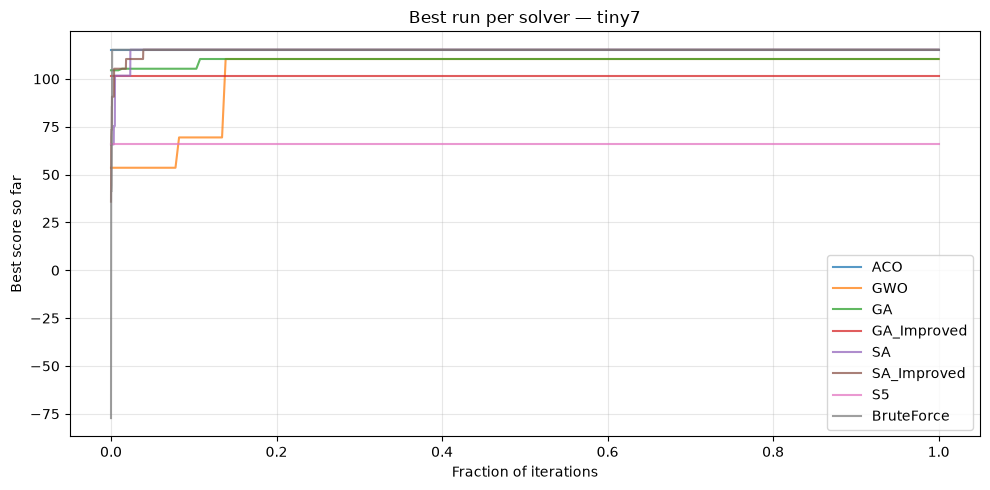

In [ ]:
# convergence of all best runs overlaid (one line per algo)
best_per_algo = [max(rs, key=lambda r: r.convergence[-1]) for rs in all_results.values()]
plot_convergence(best_per_algo, title=f"Best run per solver — {INSTANCE_NAME}")
plt.show()

In [ ]:
# scores and runtimes across all runs per solver
rows = []
for algo, rs in all_results.items():
    scores = [r.convergence[-1] for r in rs]
    runtimes = [r.runtime for r in rs]
    rows.append({
        "algo": algo,
        "best_score": max(scores),
        "mean_score": sum(scores) / len(scores),
        "worst_score": min(scores),
        "mean_runtime_s": sum(runtimes) / len(runtimes),
    })

pd.DataFrame(rows).set_index("algo").round(2)

,best_score,mean_score,worst_score,mean_runtime_s
algo,,,,
ACO,115.23,115.23,115.23,0.09
GWO,110.40,90.44,50.54,0.03
GA,110.40,109.91,108.95,0.30
GA_Improved,101.70,101.70,101.70,0.09
SA,115.23,111.53,108.95,0.11
SA_Improved,115.23,115.23,115.23,0.42
S5,65.78,65.78,65.78,0.00
Brute Force,115.23,115.23,115.23,0.25
